In [2]:
import pandas as pd

In [3]:
data= pd.read_csv('IMDB_Dataset.csv')

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
data.shape

(50000, 2)

In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

data['sentiment']=le.fit_transform(data['sentiment'])
data['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [7]:
data.columns

Index(['review', 'sentiment'], dtype='object')

In [8]:
x= data['review'].values
y= data['sentiment'].values

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=42)

In [10]:
vocab_siz= 10000
Max_len = 200 

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer= Tokenizer(num_words=vocab_siz, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
x_train_pad = pad_sequences(x_train_seq,maxlen=Max_len,padding='post',truncating='post')
x_test_pad = pad_sequences(x_test_seq,maxlen=Max_len,padding='post',truncating='post')

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Flatten

model = Sequential()

model.add(Embedding(input_dim=vocab_siz,output_dim=64,input_length=Max_len))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

C:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
h= model.fit(
    x_train_pad,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7255 - loss: 0.5102 - val_accuracy: 0.8669 - val_loss: 0.3155
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9593 - loss: 0.1172 - val_accuracy: 0.8357 - val_loss: 0.5006
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9959 - loss: 0.0178 - val_accuracy: 0.8426 - val_loss: 0.6746
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.8451 - val_loss: 0.7770
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 1.0000 - loss: 3.9773e-04 - val_accuracy: 0.8511 - val_loss: 0.8182
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 1.0000 - loss: 7.0424e-05 - val_accuracy: 0.8509 - val_loss: 0.8497
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 1.0000 - loss: 3.4892e-05 - val_accuracy: 0.8509 - val_loss: 0.8799
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 1.0000 - los

In [15]:
loss, accuracy =model.evaluate(x_test_pad,y_test,verbose=1)
print("Accuracy : ",accuracy)
print("Test Loss: ",loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8461 - loss: 0.9330
Accuracy :  0.8469333052635193
Test Loss:  0.9363391995429993


In [16]:
y_pred_prob= model.predict(x_test_pad)
y_pred= (y_pred_prob>0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


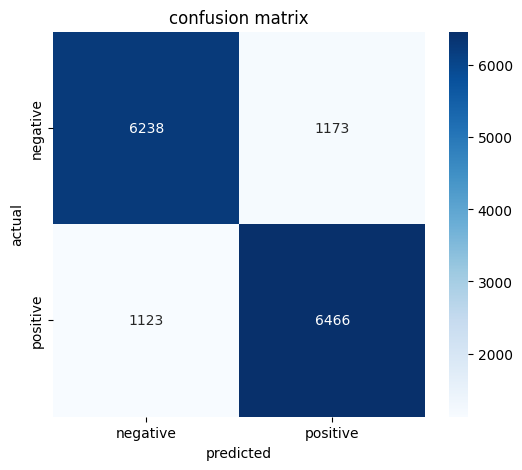

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

In [18]:
print(cm)

[[6238 1173]
 [1123 6466]]


In [19]:

# classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      7411
    positive       0.85      0.85      0.85      7589

    accuracy                           0.85     15000
   macro avg       0.85      0.85      0.85     15000
weighted avg       0.85      0.85      0.85     15000

